In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex', 'grid'])
from pathlib import Path
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

FIG_DIR = Path("/Users/michelefanelli/Documents/Thesis/Latex/Figures")
FIG_DIR.mkdir(exist_ok=True)

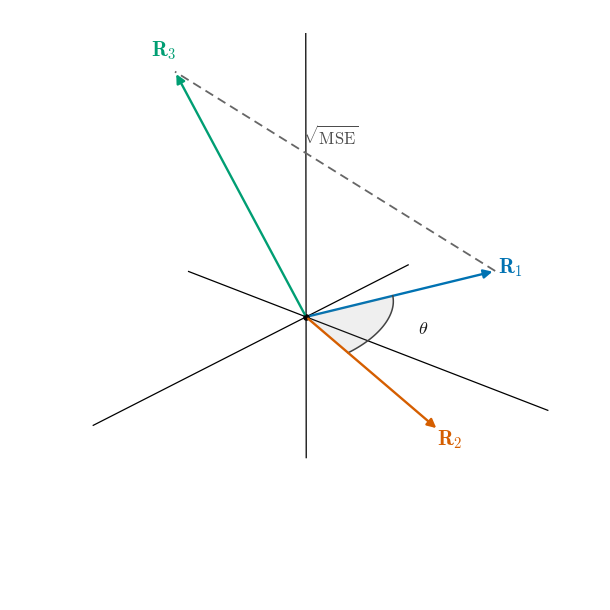

In [3]:
# Three "vectors" R_1, R_2, R_3 living in the abstract Hilbert space L^2(P).
# Nothing here is a coordinate: only the relative lengths (= volatilities) and the
# angle between two vectors (cos(theta) = <R_i,R_j>/(||R_i|| ||R_j||) = correlation)
# carry meaning. The black axes through the origin are just an arbitrary reference frame.


class Arrow3D(FancyArrowPatch):
    """A straight 3D arrow with a clean 2D-style arrowhead."""

    def __init__(self, start, vec, **kwargs):
        super().__init__((0, 0), (0, 0), **kwargs)
        self._start = np.asarray(start, float)
        self._tip = self._start + np.asarray(vec, float)

    def do_3d_projection(self, renderer=None):
        xs, ys, zs = proj_transform((self._start[0], self._tip[0]),
                                    (self._start[1], self._tip[1]),
                                    (self._start[2], self._tip[2]), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return float(np.min(zs))


# the vectors and a colour-blind-safe palette (Okabe-Ito)
R = {
    r"$\mathbf{R}_1$": (np.array([-1.5, 1.5, 0.5]), "#0072B2"),
    r"$\mathbf{R}_2$": (np.array([1.1, 2.8, 0.0]), "#D55E00"),
    r"$\mathbf{R}_3$": (np.array([1.0, -1.0, 3.0]), "#009E73"),
}

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.set_axis_off()  # no panes, grid, ticks or frame -- only what we draw

# bare black reference axes through the origin (plain lines, both directions, no heads)
for d in np.eye(3):
    p0, p1 = -1.8 * d, 3.4 * d
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
            color="black", lw=0.9, zorder=1)

# each vector as a slim arrow from the origin, with its name at the tip
for name, (v, c) in R.items():
    ax.add_artist(Arrow3D((0, 0, 0), v, mutation_scale=13, lw=1.7,
                          arrowstyle="-|>", color=c, zorder=5))
    ax.text(*(v * 1.08), name, color=c, fontsize=15, fontweight="bold",
            ha="center", va="center")

# angle between R_1 and R_2: a shaded sector + arc in their common plane
v1, v2, v3 = R[r"$\mathbf{R}_1$"][0], R[r"$\mathbf{R}_2$"][0], R[r"$\mathbf{R}_3$"][0]
u1, u2 = v1 / np.linalg.norm(v1), v2 / np.linalg.norm(v2)
theta = np.arccos(np.clip(u1 @ u2, -1, 1))
t = np.linspace(0, 1, 80)[:, None]
arc = (np.sin((1 - t) * theta) * u1 + np.sin(t * theta) * u2) / np.sin(theta)

ax.add_collection3d(Poly3DCollection([np.vstack([[0, 0, 0], arc])],
                                     facecolor="0.5", alpha=0.12, edgecolor="none"))
ax.plot(arc[:, 0], arc[:, 1], arc[:, 2], color="0.25", lw=1.1)
ax.text(*(arc[len(arc) // 2] * 1.5), rf"$\theta$",
        color="0.1", fontsize=13, ha="center", va="center")

# MSE between R_1 and R_2 in L^2: the squared length of their difference vector,
# ||R_1 - R_2||^2 = E[(R_1 - R_2)^2], drawn as the dashed gap between the two tips.
seg = np.vstack([v1,v3])
ax.plot(seg[:, 0], seg[:, 1], seg[:, 2], color="0.4", lw=1.3, ls=(0, (5, 3)), zorder=4)
mid = (v1 + v3) / 2
perp = np.array([-(v1 - v3)[1], (v1 - v3)[0], 0.0])
perp /= np.linalg.norm(perp)
ax.text(*(mid + 1 * perp), r"$\sqrt{\mathrm{MSE}}$",
        color="0.3", fontsize=12, ha="center", va="center")

ax.scatter(0, 0, 0, color="k", s=14, depthshade=False)  # origin

# fill the frame and trim the margins
ax.view_init(elev=26, azim=41)
ax.set_box_aspect((1, 1, 1), zoom=1.35)
ax.set(xlim=(-1.8, 3.4), ylim=(-1.8, 3.4), zlim=(-1.8, 3.4))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

#fig.savefig(FIG_DIR / "hilbert_vectors.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

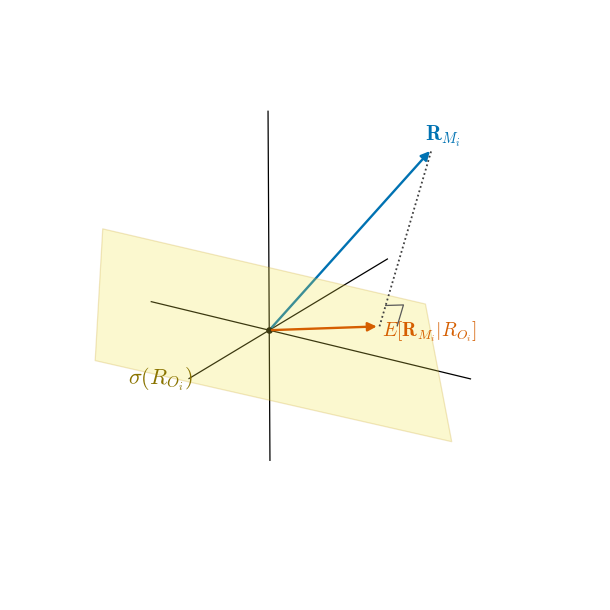

In [4]:
# Orthogonal projection of a vector R_M onto a closed subspace H (a tilted plane
# through the origin). This is the conditional-expectation picture: P_H R_M is the
# best approximation of R_M living in H, and the residual R_M - P_H R_M is
# orthogonal to H -- the dotted perpendicular, of minimal length.

# subspace H: a gently tilted plane through the origin
n = np.array([0.22, 0.15, 1.0])          # near-vertical normal -> shallow tilt
n /= np.linalg.norm(n)
e1 = np.cross(n, [0, 0, 1.0])            # horizontal in-plane direction
e1 /= np.linalg.norm(e1)
e2 = np.cross(n, e1)                      # in-plane "up the slope" direction

# a vector R_M and its orthogonal projection onto H
proj = -1 * e1 + 1.5 * e2               # P_H R_M : a vector lying in H
R_M = proj + 2.5 * n                     # rise off the plane along the normal
resid = R_M - proj                       # residual, perpendicular to H

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.set_axis_off()

# bare black reference axes through the origin (same frame as the L^2 figure)
for d in np.eye(3):
    p0, p1 = -1.8 * d, 2.9 * d
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
            color="black", lw=0.9, zorder=1)

# the subspace H as a translucent yellow parallelogram
s = 2.2
corners = np.array([s * e1 + s * e2, -s * e1 + s * e2,
                    -s * e1 - s * e2, s * e1 - s * e2])
ax.add_collection3d(Poly3DCollection([corners], facecolor="#F0E442", alpha=0.25,
                                     edgecolor="#C9A227", lw=0.9, zorder=2))
ax.text(*(1.06 * (s * e1 - 0.6 * s * e2)), r"$\sigma(R_{O_i})$", color="#8A7400",
        fontsize=16, fontstyle="italic", ha="center", va="center")

# R_M (off the plane) and its projection P_H R_M (in the plane)
ax.add_artist(Arrow3D((0, 0, 0), R_M, mutation_scale=13, lw=1.7,
                      arrowstyle="-|>", color="#0072B2", zorder=6))
ax.add_artist(Arrow3D((0, 0, 0), proj, mutation_scale=13, lw=1.7,
                      arrowstyle="-|>", color="#D55E00", zorder=5))
ax.text(*(R_M * 1.07), r"$\mathbf{R}_{M_i}$", color="#0072B2",
        fontsize=15, fontweight="bold", ha="center", va="center")
ax.text(*(proj * 1.02 + 0.18 * e1), r"$E[\mathbf{R}_{M_i}|R_{O_i}]$", color="#D55E00",
        fontsize=14, fontweight="bold", ha="left", va="center")

# the distance R_M - P_H R_M as a dotted perpendicular, with a right-angle marker
gap = np.vstack([proj, R_M])
ax.plot(gap[:, 0], gap[:, 1], gap[:, 2], color="0.25", lw=1.3,
        ls=(0, (1, 1.5)), zorder=6)
side = np.cross(resid, e1)
side /= np.linalg.norm(side)
#ax.text(*(proj + 0.55 * resid - 0.42 * side), r"$\|\mathbf{R}_M-P_H\mathbf{R}_M\|$",color="0.25", fontsize=10, ha="center", va="center")

nrm = resid / np.linalg.norm(resid)
pin = proj / np.linalg.norm(proj)
k = 0.30
sq = np.array([proj + k * pin, proj + k * pin + k * nrm, proj + k * nrm])
ax.plot(sq[:, 0], sq[:, 1], sq[:, 2], color="0.35", lw=0.9, zorder=6)

ax.scatter(0, 0, 0, color="k", s=14, depthshade=False)  # origin

ax.view_init(elev=22, azim=-58)
ax.set_box_aspect((1, 1, 1), zoom=1.25)
lim = (-2.4, 3.2)
ax.set(xlim=lim, ylim=lim, zlim=lim)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

fig.savefig(FIG_DIR / "projection_H.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

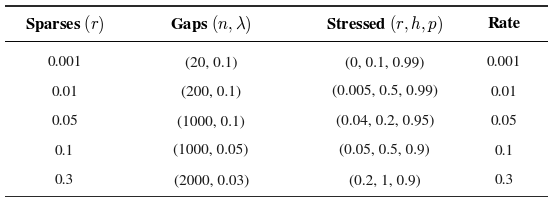

In [14]:
# ------------------------------------------------------------------
# Missingness design table -> Figures/missingness_table.pdf
# One row per intensity level; each column holds the parameter values that name the
# corresponding corrupted dataset (in the order they were generated). `Rate` is the
# target expected missingness ratio (= the Sparses rate) that Gaps and Stressed are
# calibrated to match. Rendered booktabs-style for inclusion in the LaTeX document.
# ------------------------------------------------------------------
cols = [r"Sparses $(r)$", r"Gaps $(n, \lambda)$", r"Stressed $(r,h,p)$", r"Rate"]
rows = [
    ["0.001", "(20, 0.1)",   "(0, 0.1, 0.99)",     "0.001"],
    ["0.01",  "(200, 0.1)",  "(0.005, 0.5, 0.99)", "0.01"],
    ["0.05",  "(1000, 0.1)", "(0.04, 0.2, 0.95)",  "0.05"],
    ["0.1",   "(1000, 0.05)", "(0.05, 0.5, 0.9)",   "0.1"],
    ["0.3",   "(2000, 0.03)", "(0.2, 1, 0.9)",      "0.3"],
]

x = [0.11, 0.38, 0.70, 0.92]              # column centres (Stressed gets the widest slot)
y_rows = np.linspace(0.70, 0.09, len(rows))

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axis("off")
ax.set(xlim=(0, 1), ylim=(0, 1))

# booktabs-style rules: heavy top/bottom, light under the header
for yv, lw in [(0.99, 1.2), (0.81, 0.7), (0.00, 1.2)]:
    ax.plot([0, 1], [yv, yv], color="black", lw=lw, transform=ax.transAxes)

for xi, name in zip(x, cols):             # header
    ax.text(xi, 0.90, name, ha="center", va="center",
            fontsize=12, fontweight="bold", family="serif")

for yi, row in zip(y_rows, rows):         # body
    for xi, val in zip(x, row):
        ax.text(xi, yi, val, ha="center", va="center",
                fontsize=11, family="serif", color="0.1")

fig.savefig(FIG_DIR / "missingness_table.pdf", bbox_inches="tight", pad_inches=0.03)
plt.show()